# Data analysis notebook

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(Path().resolve().parent))

from config import RAW_DATA_DIR, PROCESSED_DATA_DIR, STATIONS

In [2]:
import json
import requests

from datetime import datetime, timedelta, timezone
from pprint import pprint

import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Loading data

In [3]:
milan_lampugnano_df = pd.read_csv(PROCESSED_DATA_DIR / 'milan_lampugnano_departures.csv')
genoa_principe_df = pd.read_csv(PROCESSED_DATA_DIR / 'genoa_principe_departures.csv')

In [4]:
milan_lampugnano_df.head()

,ride_id,bus_code,direction,name,deviation_seconds,updated_at,scheduled_timestamp,snapshot_time
0,23c8dea6-ab2f-429c-ba95-545b24835042,N456,"Lublin, Bus Station Lublin",Lublin - Milan - Marseille,2859.0,2026-05-20T16:12:41Z,2026-05-20T16:35:00Z,2026-05-20T18:18:17
1,279429f3-5d1a-4c7b-a7f8-b2d520720fc8,518,Como,Naples - Milan - Como,0.0,2026-05-20T04:48:55Z,2026-05-20T17:25:00Z,2026-05-20T18:18:17
2,f54c0343-266b-4ebc-804e-0228733d2e5a,423,Turin (Vittorio Emanuele),Turin - Ferrara,263.0,2026-05-20T16:18:27Z,2026-05-20T17:30:00Z,2026-05-20T18:18:17
3,afeed613-2e47-4b8a-865d-ea644648ff3d,N836,Amsterdam Sloterdijk,Amsterdam - Brussels - Luxemburg - Milan,NaN,NaN,2026-05-20T17:40:00Z,2026-05-20T18:18:17
4,7f008d8a-46b9-4a06-9fa6-4a01f7294883,CIT3197,Milan (Malpensa Airport Terminal 1),Standard,NaN,NaN,2026-05-20T17:45:00Z,2026-05-20T18:18:17


In [5]:
genoa_principe_df.head()

,ride_id,bus_code,direction,name,deviation_seconds,updated_at,scheduled_timestamp,snapshot_time
0,4a8a8865-2806-4f83-869e-bda601b25a60,501,Turin (Vittorio Emanuele),Turin - Naples,0.0,2026-05-20T16:12:24Z,2026-05-20T17:55:00Z,2026-05-20T18:18:17
1,c36a991e-02a2-4da2-b7b0-6a0bf3f1979f,N758,Barcelona (Bus Terminal Nord),Florence - Barcelona,0.0,2026-05-20T16:16:23Z,2026-05-20T19:25:00Z,2026-05-20T18:18:17
2,fb971887-fb5f-4f70-9ee3-51f98e2df1f0,N177,Düsseldorf central bus station,Düsseldorf - Genoa,NaN,NaN,2026-05-20T19:30:00Z,2026-05-20T18:18:17
3,0aa24a02-20c3-4546-a0da-7204720f792e,N728,Munich central bus station,Munich/Genoa - Barcelona,0.0,2026-05-20T06:52:32Z,2026-05-20T21:05:00Z,2026-05-20T18:18:17
4,3e59c7ef-b056-405d-a477-9fe1df21eeb9,N504,Perugia (Piazza Partigiani),Geneva - Turin - Perugia,0.0,2026-05-20T16:09:23Z,2026-05-20T21:20:00Z,2026-05-20T18:18:17


Concatenate these two dataframes:

In [6]:
milan_lampugnano_df['station'] = 'Milan Lampugnano'
genoa_principe_df['station'] = 'Genoa Principe'

df = pd.concat([milan_lampugnano_df, genoa_principe_df], ignore_index=True)

In [7]:
df.head()

,ride_id,bus_code,direction,name,deviation_seconds,updated_at,scheduled_timestamp,snapshot_time,station
0,23c8dea6-ab2f-429c-ba95-545b24835042,N456,"Lublin, Bus Station Lublin",Lublin - Milan - Marseille,2859.0,2026-05-20T16:12:41Z,2026-05-20T16:35:00Z,2026-05-20T18:18:17,Milan Lampugnano
1,279429f3-5d1a-4c7b-a7f8-b2d520720fc8,518,Como,Naples - Milan - Como,0.0,2026-05-20T04:48:55Z,2026-05-20T17:25:00Z,2026-05-20T18:18:17,Milan Lampugnano
2,f54c0343-266b-4ebc-804e-0228733d2e5a,423,Turin (Vittorio Emanuele),Turin - Ferrara,263.0,2026-05-20T16:18:27Z,2026-05-20T17:30:00Z,2026-05-20T18:18:17,Milan Lampugnano
3,afeed613-2e47-4b8a-865d-ea644648ff3d,N836,Amsterdam Sloterdijk,Amsterdam - Brussels - Luxemburg - Milan,NaN,NaN,2026-05-20T17:40:00Z,2026-05-20T18:18:17,Milan Lampugnano
4,7f008d8a-46b9-4a06-9fa6-4a01f7294883,CIT3197,Milan (Malpensa Airport Terminal 1),Standard,NaN,NaN,2026-05-20T17:45:00Z,2026-05-20T18:18:17,Milan Lampugnano


Adding a column is very simple from the existing data:

In [8]:
df['deviation_minutes'] = df['deviation_seconds'] / 60

In [ ]:
df['deviation_minutes'].describe()

In [ ]:
df['deviation_minutes'].hist(bins=50)
plt.xlabel('Delay [minutes]')
plt.ylabel('Frequency')
plt.title('Distribution of Flixbus Delays')
plt.show()

This isn't a good measure because we are snapshotting all the time - so the same delay appears for a finite snapshot range/or until the bus gets back to the schedule. It might make sense that for EACH ride I check the delay, how it changes with time, or at a specific point - idk, when it arrives at the station or something like this.

In [ ]:
df.groupby('station')['deviation_minutes'].describe()

In [ ]:
df.groupby('bus_code')['deviation_minutes'].describe()

In [ ]:
df.groupby('bus_code')['deviation_minutes'].hist(bins=10)
plt.xlabel('Delay [minutes]')
plt.ylabel('Frequency')
plt.title('Distribution of Flixbus Delays')
plt.show()

## Cleaning

Let's take care of the date formatting. Format the time uniformly:

In [9]:
df['snapshot_time'] = pd.to_datetime(df['snapshot_time'])
df['scheduled_timestamp'] = pd.to_datetime(df['scheduled_timestamp'])
df['updated_at'] = pd.to_datetime(df['updated_at'])

In [ ]:
df.head()

### How to use df.resample

resample does a similar thing like groupby(). Here is the basic usage:

In [ ]:
df_snapshot_time = df.set_index('snapshot_time') # now the data is sorted by the time we took the snapshot of the data, which is when we observed the delay. This allows us to analyze how delays evolve over time leading up to the scheduled departure time.

In [ ]:
df_snapshot_time.head()

Resample hourly:

In [ ]:
hourly = df.resample("1h")['deviation_seconds']

In [ ]:
df.resample("1h").size()

In [ ]:
hourly.size()

In [ ]:
hourly.mean()

Note that df.resample('1h').mean() doesn't work if we include THE WHOLE DATAFRAME. Because then pandas tries to get a mean of all the columns, including string columns like name, direction etc.

In [ ]:
hourly.mean().plot()
plt.xlabel('snapshot time')
plt.ylabel('Average Delay [seconds]')
plt.title('Average Flixbus Delay Over Time')
plt.show()

However, this plot and these information do not make sense, since we are averaging over a couple of snapshots, and also different rides. 
The information have sense if we fix a ride (using the unique ride ID or the name of the line (N458 for example) WITH THE SAME DESTINATION), and then, for each snapshot time, check the delay.

We can do the following: First, create time bins, as we had them before. Then group the data by the hour and the ride_id. And take maybe only the last point. 
Still, I think the most relevant quantities/plots are the delays for each specific line and stuff. 

In [ ]:
df_hourly_grouped = df.groupby([pd.Grouper(freq='1h'), 'ride_id'])

In [ ]:
df_hourly_grouped = df_hourly_grouped.last()

In [ ]:
df_hourly_grouped.head(45)

In [ ]:
df_hourly_grouped.groupby(level=0)['deviation_seconds'].mean()

In [ ]:
df_hourly_grouped.groupby(level=1)['deviation_seconds'].mean()

I think the "last hour" kind of thing isn't really the relevant quantity. The relevant quantity of the delay is when the bus, actually, is AT the station. That's then relevant. However, how can I extract this data? 
It can happen that with my timestamps either the bus is just a bit before the station there or he left the station. Actually also after he left the station, that's very relevant. So basically, THE CLOSEST TIMESTAMP TO WHEN THE BUS ARRIVES AT THE STATION is the most relevant in principle. \
Otherwise, the timestamps MAKE sense if I plot FOR EACH RIDE ID a plot...\
There's nothing special about runding the hours up...The other thing..hm idk.

In [ ]:
df

To set something as an index, you use df.set_index('id'). If you want to SORT in terms of this index, then we use sort_index().

In [ ]:
df_id_grouped = df.set_index('ride_id').sort_index()

In [ ]:
df_id_grouped

If we want to group structurally, in terms of id and the snapshot time, we do this:

In [ ]:
#df_something = df.set_index(["ride_id", "snapshot_time"]).sort_index()

Or like this:

In [ ]:
#df2 = df.sort_values(["ride_id", "snapshot_time"])
#df2 = df2.set_index(["ride_id", "snapshot_time"])

In [ ]:
#df2

Then let's do this:

In [10]:
df_sorted_id = df.set_index(["ride_id", "snapshot_time"]).sort_index()

In [11]:
df_sorted_id

bus_code  \
ride_id                              snapshot_time                  
0055e4aa-e222-4070-886d-9e4944044517 2026-05-22 10:19:45     N456   
                                     2026-05-22 10:29:45     N456   
                                     2026-05-22 10:39:45     N456   
                                     2026-05-22 10:49:46     N456   
                                     2026-05-22 10:59:46     N456   
...                                                           ...   
ff064e52-347a-4123-b236-06b49a8a9bab 2026-05-21 15:19:02      492   
                                     2026-05-21 15:29:02      492   
                                     2026-05-21 15:39:03      492   
                                     2026-05-21 15:49:03      492   
                                     2026-05-21 15:59:03      492   

                                                                                        direction  \
ride_id                              snapshot_time                                                  
0055e4aa-e222-4070-886d-9e4944044517 2026-05-22 10:19:45               Lublin, Bus Station Lublin   
                                     2026-05-22 10:29:45               Lublin, Bus Station Lublin   
                                     2026-05-22 10:39:45               Lublin, Bus Station Lublin   
                                     2026-05-22 10:49:46               Lublin, Bus Station Lublin   
                                     2026-05-22 10:59:46               Lublin, Bus Station Lublin   
...                                                                                           ...   
ff064e52-347a-4123-b236-06b49a8a9bab 2026-05-21 15:19:02  Nice Airport (Bus Station - Terminal 1)   
                                     2026-05-21 15:29:02  Nice Airport (Bus Station - Terminal 1)   
                                     2026-05-21 15:39:03  Nice Airport (Bus Station - Terminal 1)   
                                     2026-05-21 15:49:03  Nice Airport (Bus Station - Terminal 1)   
                                     2026-05-21 15:59:03  Nice Airport (Bus Station - Terminal 1)   

                                                                                            name  \
ride_id                              snapshot_time                                                 
0055e4aa-e222-4070-886d-9e4944044517 2026-05-22 10:19:45              Lublin - Milan - Marseille   
                                     2026-05-22 10:29:45              Lublin - Milan - Marseille   
                                     2026-05-22 10:39:45              Lublin - Milan - Marseille   
                                     2026-05-22 10:49:46              Lublin - Milan - Marseille   
                                     2026-05-22 10:59:46              Lublin - Milan - Marseille   
...                                                                                          ...   
ff064e52-347a-4123-b236-06b49a8a9bab 2026-05-21 15:19:02  Munich - Milan- Genoa - Nice Airport ✈   
                                     2026-05-21 15:29:02  Munich - Milan- Genoa - Nice Airport ✈   
                                     2026-05-21 15:39:03  Munich - Milan- Genoa - Nice Airport ✈   
                                     2026-05-21 15:49:03  Munich - Milan- Genoa - Nice Airport ✈   
                                     2026-05-21 15:59:03  Munich - Milan- Genoa - Nice Airport ✈   

                                                          deviation_seconds  \
ride_id                              snapshot_time                            
0055e4aa-e222-4070-886d-9e4944044517 2026-05-22 10:19:45                0.0   
                                     2026-05-22 10:29:45                0.0   
                                     2026-05-22 10:39:45                0.0   
                                     2026-05-22 10:49:46                0.0   
                                     2026-05-22 10:59:46              

What's the next thing to do? Let's plot for one ride id these things.
Note that IF YOU SET SOMETHING AS AN INDEX, TO ACCESS IT, it's a bit different than how you do it from a "normal" DataFrame, where we haven't set some value as an index. \
So, to access for example the ID of a ride, it's not the same for the df and for df_sorted_id. 


In [12]:
df.iloc[0]

ride_id                23c8dea6-ab2f-429c-ba95-545b24835042
bus_code                                               N456
direction                        Lublin, Bus Station Lublin
name                             Lublin - Milan - Marseille
deviation_seconds                                    2859.0
updated_at                        2026-05-20 16:12:41+00:00
scheduled_timestamp               2026-05-20 16:35:00+00:00
snapshot_time                           2026-05-20 18:18:17
station                                    Milan Lampugnano
deviation_minutes                                     47.65
Name: 0, dtype: object

In [ ]:
df.loc[0]

In [ ]:
df_sorted_id.iloc[1]

Plot for the first ride:

In [ ]:
df_sorted_id.loc['ff064e52-347a-4123-b236-06b49a8a9bab']

One plot:

In [24]:
df_sorted_id

bus_code  \
ride_id                              snapshot_time                  
0055e4aa-e222-4070-886d-9e4944044517 2026-05-22 10:19:45     N456   
                                     2026-05-22 10:29:45     N456   
                                     2026-05-22 10:39:45     N456   
                                     2026-05-22 10:49:46     N456   
                                     2026-05-22 10:59:46     N456   
...                                                           ...   
ff064e52-347a-4123-b236-06b49a8a9bab 2026-05-21 15:19:02      492   
                                     2026-05-21 15:29:02      492   
                                     2026-05-21 15:39:03      492   
                                     2026-05-21 15:49:03      492   
                                     2026-05-21 15:59:03      492   

                                                                                        direction  \
ride_id                              snapshot_time                                                  
0055e4aa-e222-4070-886d-9e4944044517 2026-05-22 10:19:45               Lublin, Bus Station Lublin   
                                     2026-05-22 10:29:45               Lublin, Bus Station Lublin   
                                     2026-05-22 10:39:45               Lublin, Bus Station Lublin   
                                     2026-05-22 10:49:46               Lublin, Bus Station Lublin   
                                     2026-05-22 10:59:46               Lublin, Bus Station Lublin   
...                                                                                           ...   
ff064e52-347a-4123-b236-06b49a8a9bab 2026-05-21 15:19:02  Nice Airport (Bus Station - Terminal 1)   
                                     2026-05-21 15:29:02  Nice Airport (Bus Station - Terminal 1)   
                                     2026-05-21 15:39:03  Nice Airport (Bus Station - Terminal 1)   
                                     2026-05-21 15:49:03  Nice Airport (Bus Station - Terminal 1)   
                                     2026-05-21 15:59:03  Nice Airport (Bus Station - Terminal 1)   

                                                                                            name  \
ride_id                              snapshot_time                                                 
0055e4aa-e222-4070-886d-9e4944044517 2026-05-22 10:19:45              Lublin - Milan - Marseille   
                                     2026-05-22 10:29:45              Lublin - Milan - Marseille   
                                     2026-05-22 10:39:45              Lublin - Milan - Marseille   
                                     2026-05-22 10:49:46              Lublin - Milan - Marseille   
                                     2026-05-22 10:59:46              Lublin - Milan - Marseille   
...                                                                                          ...   
ff064e52-347a-4123-b236-06b49a8a9bab 2026-05-21 15:19:02  Munich - Milan- Genoa - Nice Airport ✈   
                                     2026-05-21 15:29:02  Munich - Milan- Genoa - Nice Airport ✈   
                                     2026-05-21 15:39:03  Munich - Milan- Genoa - Nice Airport ✈   
                                     2026-05-21 15:49:03  Munich - Milan- Genoa - Nice Airport ✈   
                                     2026-05-21 15:59:03  Munich - Milan- Genoa - Nice Airport ✈   

                                                          deviation_seconds  \
ride_id                              snapshot_time                            
0055e4aa-e222-4070-886d-9e4944044517 2026-05-22 10:19:45                0.0   
                                     2026-05-22 10:29:45                0.0   
                                     2026-05-22 10:39:45                0.0   
                                     2026-05-22 10:49:46                0.0   
                                     2026-05-22 10:59:46              

In [31]:
df_sorted_id.index.get_level_values("ride_id").unique()[4]

'028f02d7-cbae-4cb1-ad3d-6ba28b9f47d2'

0aa24a02-20c3-4546-a0da-7204720f792e


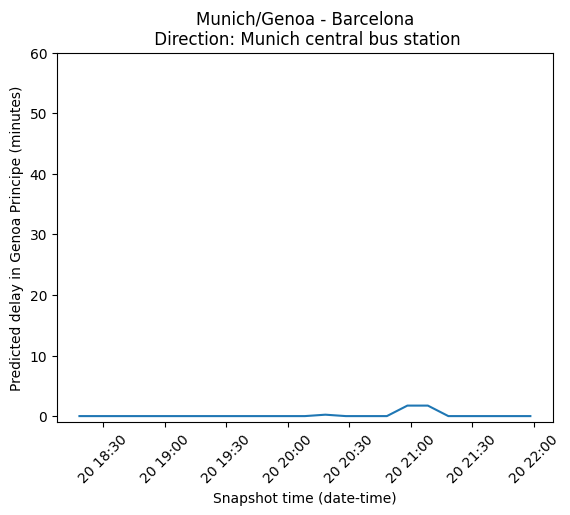

In [59]:
#The station has to be chosen before! We slice in terms of the station too

station= "Genoa Principe"
sub_station = df_sorted_id[df_sorted_id["station"] == station]

ride_id = sub_station.index.get_level_values("ride_id").unique()[6] # There has to be unique because without it, you get a slice of the dataframe instead of a single ride, which is not what we want. 
print(ride_id)
sub_station = sub_station.loc[ride_id] # Here we are slicing the dataframe to get all the rows that belong to the same ride, which is identified by the ride_id. This allows us to analyze the delay for a specific ride over time leading up to the scheduled departure time.

sub_station = sub_station.sort_index() # Guarantees proper line plotting order, although it should already be sorted by snapshot time. Never hurts to be sure.

line_name = sub_station['name'].iloc[0] # The .iloc[0] is used to get the first value of the 'name' column, which is the same for all rows in the sub dataframe since they all belong to the same ride and station.
direction = sub_station['direction'].iloc[0] 



plt.plot(sub_station.index, sub_station["deviation_minutes"]) # The sub_station.index is the snapshot time, which is the time we observed the delay, and the sub_station["deviation_minutes"] is the predicted delay in minutes at that snapshot time. This allows us to see how the predicted delay evolves over time leading up to the scheduled departure time.
plt.title(f"{line_name}\n Direction: {direction}")
plt.xlabel("Snapshot time (date-time)")
plt.ylabel(f"Predicted delay in {station} (minutes)")
plt.xticks(rotation=45)
plt.ylim(-1, 60)
plt.show()

In [14]:
df_sorted_id.index.get_level_values("ride_id").unique()

Index(['0055e4aa-e222-4070-886d-9e4944044517',
       '01216951-be55-410d-80f7-2297b4e13319',
       '018646b9-d0ce-468a-9002-7c6b76728d17',
       '025ac9a2-dac7-4ed5-b97b-77c7b8ba4a06',
       '028f02d7-cbae-4cb1-ad3d-6ba28b9f47d2',
       '02c28883-82f8-4a5e-be34-bb1de07a2f24',
       '036c891d-c0e6-4ebb-a4e1-9d409a6c314b',
       '049b6dd5-f2f9-4a9d-b8b9-2745ce2e7651',
       '04c8296b-9698-4e9e-b497-167c15b688ca',
       '04e1a40b-9f4b-468a-abfa-a3132e7fd348',
       ...
       'faee0959-5ca8-42c9-836d-a913eccc1021',
       'fb096836-26c1-4588-adc9-4665e6bbee78',
       'fb1c81d0-f67b-45e8-8afb-a4c478a4cf67',
       'fb971887-fb5f-4f70-9ee3-51f98e2df1f0',
       'fb9d9f3c-1744-4a27-b72a-26f29d2b1eb5',
       'fbdaeed8-7bc1-4caa-a2b6-195f32d0a0f6',
       'fbf48731-39ce-4c28-b898-152ae6ddaabf',
       'fd0702be-8403-4b91-81fe-9ba6a1a7847e',
       'fdda9cdd-ead9-4dd5-b337-35a684877cf4',
       'ff064e52-347a-4123-b236-06b49a8a9bab'],
      dtype='str', name='ride_id', length=481)

01216951-be55-410d-80f7-2297b4e13319
                    bus_code            direction                  name  \
snapshot_time                                                             
2026-05-21 10:38:51      482  Venice (Tronchetto)  Venice - Montpellier   
2026-05-21 10:48:51      482  Venice (Tronchetto)  Venice - Montpellier   
2026-05-21 10:58:51      482  Venice (Tronchetto)  Venice - Montpellier   
2026-05-21 11:08:52      482  Venice (Tronchetto)  Venice - Montpellier   
2026-05-21 11:18:52      482  Venice (Tronchetto)  Venice - Montpellier   
2026-05-21 11:28:52      482  Venice (Tronchetto)  Venice - Montpellier   
2026-05-21 11:38:53      482  Venice (Tronchetto)  Venice - Montpellier   
2026-05-21 11:48:53      482  Venice (Tronchetto)  Venice - Montpellier   
2026-05-21 11:58:53      482  Venice (Tronchetto)  Venice - Montpellier   
2026-05-21 12:08:54      482  Venice (Tronchetto)  Venice - Montpellier   
2026-05-21 12:18:54      482  Venice (Tronchetto)  Venice - Mon

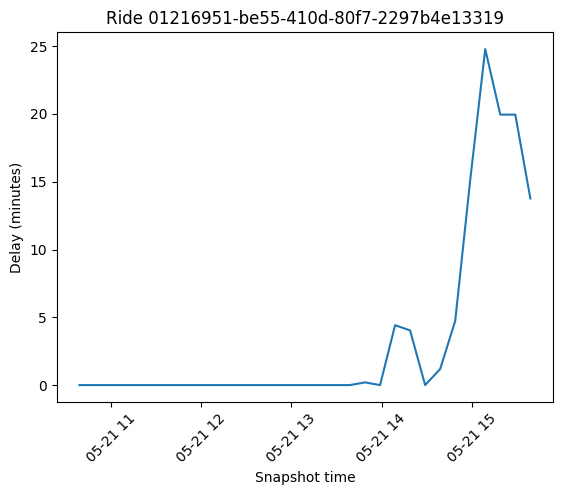

In [17]:
ride_id = '01216951-be55-410d-80f7-2297b4e13319' # There has to be unique because without it, you get a slice of the dataframe instead of a single ride, which is not what we want. 
sub = df_sorted_id.loc[ride_id]
print(ride_id)
pprint(sub)
plt.plot(sub.index, sub["deviation_minutes"])
plt.title(f"Ride {ride_id}")
plt.xlabel("Snapshot time")
plt.ylabel("Delay (minutes)")
plt.xticks(rotation=45)
plt.show()